# 📘 Week 3 Practical and Revision Workbook
## Interpolation, Noise, Newton Polynomials, Splines, 2D Fields and ML-style Interpolation

This is the **student activity notebook** for the whole week. Begin the workbook in **Wednesday's practical class**. You are not expected to complete
any workbook activities before Wednesday. Aim to complete Activities 1–6 in the practical,
then finish remaining work and Activities 7–9 during study or homework. Code cells marked `TODO` are intended to be changed.

The Week 3 notes contain the worked demonstrations. This workbook is where you predict,
modify, test, explain and justify. If you missed Monday or are still reviewing, follow the
topic links in each activity and begin with Activity 1.


# 🧭 Weekly workflow and expected effort

| Phase | Purpose | Workbook expectation |
|---|---|---|
| Before Wednesday | Review the Week 3 notes and Monday workshop material | Do not start the workbook |
| Wednesday practical | Begin the workbook with staff support | Prioritise Activities 1–6 |
| Study and homework | Finish incomplete practical work and consolidate | Activities 7–9 and project bridge |

You are expected to have reviewed the Week 3 notes and Monday workshop material before the
practical, but you are **not** expected to have completed any workbook activities. Students
who missed Monday should use the notes links in each activity and ask teaching staff where to
begin. Students who have already reviewed everything may work ahead and use staff time for
questions and deeper investigation.

> ### ⚠️ Scope for the first mid-semester test
>
> Weeks 1–3 are assessable. Expect to interpret results, distinguish methods, perform small
> hand calculations, diagnose unsupported predictions and justify an engineering choice.
> The test is not a memory contest for SciPy function names.


# ✅ Before Wednesday's practical

You do not need to open or complete this workbook before Wednesday. You should, where
possible, have reviewed the six Week 3 notes and the Monday workshop material.

Before beginning, check whether you can broadly explain:

1. interpolation compared with extrapolation;
2. exact interpolation compared with fitting noisy data;
3. why high-degree polynomials may behave poorly;
4. regular-grid compared with scattered 2D data.

If any of these remain unclear or if you missed Monday, start with Activity 1 and follow the
linked notes sections. Ask teaching staff for help as you work. The workbook is designed to
support review as well as extension.


# 🧭 Purpose

This workbook begins in Wednesday's practical and turns the Week 3 demonstrations into
guided engineering decisions. Activities 1–6 are the practical core. They ask you to:

* identify supported and unsupported predictions;
* recognise noise and overfitting;
* build and interpret a Newton interpolant;
* compare spline behaviour;
* work with regular-grid and scattered 2D data;
* connect interpolation with machine learning regression.

Complete as much of Activities 1–6 as possible during the practical. Finish incomplete work
and the revision activities during study or homework.


# 🎯 Learning Objectives

By the end of this workshop, you should be able to:

* classify predictions as interpolation or extrapolation;
* compare linear interpolation, cubic splines, PCHIP and global polynomial interpolation;
* explain why exact interpolation can fail for noisy data;
* build and evaluate a Newton interpolating polynomial;
* use validation error to identify possible overfitting;
* apply 2D interpolation to regular-grid and scattered data;
* explain why machine learning regression can behave like interpolation;
* justify interpolation method choices for engineering data.

# 🔗 Unit Learning Outcome Alignment

This workshop supports:

* **LO1:** Assess the suitability and limitations of machine learning for current and emerging engineering applications.
* **LO2:** Demonstrate effective use of numerical analysis and machine learning tools to develop defensible solutions to open-ended engineering problems.
* **LO3:** Apply appropriate mathematical and numerical techniques to solve common engineering problems, and evaluate program performance, error, stability and accuracy.

# 📚 Week 3 notes map

Complete the six Week 3 notes notebooks before Monday's workshop. Return to the relevant
sections during each activity.

| Activity | Relevant notes sections |
|---|---|
| 1 | 3.1.2 and 3.1.4–3.1.7 |
| 2 | 3.2.1–3.2.8 and 3.2.13 |
| 3 | 3.3.2–3.3.9 |
| 4 | 3.4.5–3.4.10 and 3.4.16 |
| 5 | 3.5.2, 3.5.5–3.5.14 and 3.5.18 |
| 6 | 3.6.3–3.6.11 and 3.6.17 |
| 7 | 3.1.1–3.1.2, 3.3.2–3.3.5, 3.4.9 and 3.5.14 |
| 8 | 3.2.6–3.2.7 and 3.6.17 |
| 9 | 3.6.15 |

External software documentation is provided at the end of the workbook.


In [1]:
# Core imports for Workshop 3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from scipy.interpolate import (
    make_interp_spline,
    CubicSpline,
    PchipInterpolator,
    RegularGridInterpolator,
    griddata
)

from scipy.spatial import Delaunay

from numpy.polynomial import Polynomial

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.metrics import mean_squared_error

pd.set_option("display.precision", 5)


def rmse(y_true, y_pred):
    """
    Root mean squared error.
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))


def classify_1d_query(x_query, x_data):
    """
    Classify 1D query points as interpolation or extrapolation.
    """
    x_query = np.atleast_1d(x_query).astype(float)
    x_data = np.asarray(x_data, dtype=float)

    labels = np.where(
        (x_query >= np.min(x_data)) & (x_query <= np.max(x_data)),
        "interpolation",
        "extrapolation"
    )

    if labels.size == 1:
        return labels[0]

    return labels


def classify_regular_grid_points(query_points, x_axis, y_axis):
    """
    Classify 2D query points as interpolation or extrapolation
    for a rectangular or rectilinear grid.
    """
    query_points = np.asarray(query_points, dtype=float)

    inside_x = (
        (query_points[:, 0] >= np.min(x_axis)) &
        (query_points[:, 0] <= np.max(x_axis))
    )

    inside_y = (
        (query_points[:, 1] >= np.min(y_axis)) &
        (query_points[:, 1] <= np.max(y_axis))
    )

    return np.where(inside_x & inside_y, "interpolation", "extrapolation")


# 🛠️ Workshop Activities

The workbook contains six practical activities and three revision activities.

| Activity | Main topic | Approximate focus |
|---|---|---|
| Activity 1 | Interpolation vs extrapolation | Method comparison and safety checks |
| Activity 2 | Noise and overfitting | Training error vs validation error |
| Activity 3 | Newton interpolation | Divided differences and polynomial evaluation |
| Activity 4 | Spline selection | Cubic splines vs PCHIP near a peak |
| Activity 5 | 2D interpolation | Regular-grid and scattered-data interpolation |
| Activity 6 | ML-style interpolation | KNN regression and training-domain checks |

Activities 1–6 begin in Wednesday's practical. Activities 7–9 are for revision and home study. You do not need to complete every extension question during class. Prioritise understanding, discussion and interpretation.


# 🟩 Wednesday practical — core work (Activities 1–6)

This is the first point at which you are expected to work in the workbook. Prioritise the six
core activities below.

| Activity | Focus | Suggested time |
|---|---|---:|
| 1 | Interpolation and extrapolation | 10 min |
| 2 | Noise and overfitting | 15 min |
| 3 | Newton interpolation | 20 min |
| 4 | Spline selection | 15 min |
| 5 | 2D interpolation | 25 min |
| 6 | ML-style interpolation | 20 min |

Use **predict → run → explain → test**. If you need review, follow the linked notes. If you
are ready to work ahead, test another query or ask staff about assumptions and limitations.


# Activity 1 — Interpolation vs Extrapolation

You are given a synthetic airfoil lift coefficient lookup table.

The independent variable is angle of attack:

$$
\alpha
$$

The dependent variable is lift coefficient:

$$
C_L
$$

Your task is to compare several interpolation methods and identify which requested predictions are extrapolations.

> **Review before starting:** Topics **3.1.2, 3.1.4, 3.1.5 and 3.1.6**.

### Questions

1. Classify each query as interpolation or extrapolation.
2. Which methods refuse unsupported queries, and which still return a number?
3. Why is a returned number not evidence that the prediction is reliable?


In [2]:
# Synthetic airfoil-like lookup table

alpha_deg = np.array([-6, -3, 0, 3, 6, 9, 12, 15, 18], dtype=float)

cl_table = np.array([
    -0.58,
    -0.31,
     0.00,
     0.32,
     0.65,
     0.94,
     1.12,
     1.05,
     0.74
], dtype=float)

airfoil_table = pd.DataFrame({
    "alpha_deg": alpha_deg,
    "CL": cl_table
})

display(airfoil_table)


,alpha_deg,CL
0,-6.0,-0.58
1,-3.0,-0.31
2,0.0,0.00
3,3.0,0.32
4,6.0,0.65
5,9.0,0.94
6,12.0,1.12
7,15.0,1.05
8,18.0,0.74


In [10]:
# Build interpolation models

linear_interp = make_interp_spline(alpha_deg, cl_table, k=1)

cubic_interp = CubicSpline(
    alpha_deg,
    cl_table,
    bc_type="natural",
    extrapolate=False
)

pchip_interp = PchipInterpolator(
    alpha_deg,
    cl_table,
    extrapolate=False
)

global_poly = Polynomial.fit(
    alpha_deg,
    cl_table,
    deg=len(alpha_deg) - 1,
    domain=[alpha_deg.min(), alpha_deg.max()]
)

# TODO: Change these query angles and rerun.
activity1_query = np.array([-9.0, -2.0, 7.5, 13.5, 20.0], dtype=float)

activity1_table = pd.DataFrame({
    "alpha_deg": activity1_query,
    "region": classify_1d_query(activity1_query, alpha_deg),
    "linear_CL": linear_interp(activity1_query),
    "cubic_natural_CL": cubic_interp(activity1_query),
    "pchip_CL": pchip_interp(activity1_query),
    "global_poly_CL": global_poly(activity1_query)
})

activity1_table


,alpha_deg,region,linear_CL,cubic_natural_CL,pchip_CL,global_poly_CL
0,-9.0,extrapolation,-0.85000,NaN,NaN,0.17000
1,-2.0,interpolation,-0.20667,-0.21011,-0.21020,-0.20484
2,7.5,interpolation,0.79500,0.80308,0.80582,0.80343
3,13.5,interpolation,1.08500,1.12071,1.09928,1.12673
4,20.0,extrapolation,0.53333,NaN,NaN,1.00320


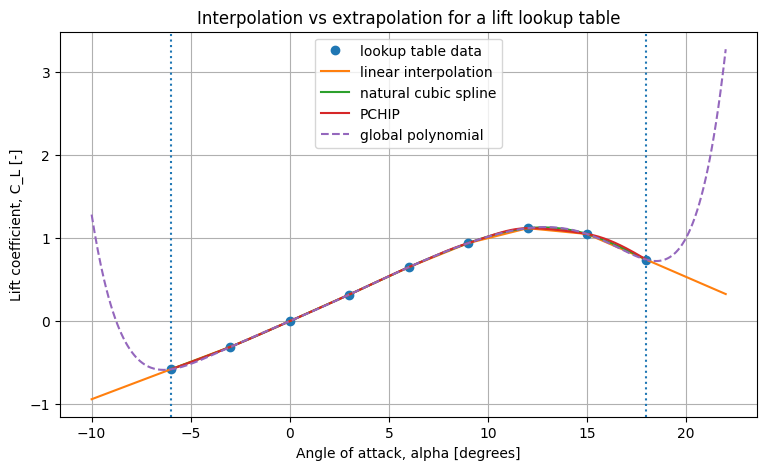

In [11]:
alpha_plot = np.linspace(-10, 22, 600)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(alpha_deg, cl_table, "o", label="lookup table data")
ax.plot(alpha_plot, linear_interp(alpha_plot), label="linear interpolation")
ax.plot(alpha_plot, cubic_interp(alpha_plot), label="natural cubic spline")
ax.plot(alpha_plot, pchip_interp(alpha_plot), label="PCHIP")
ax.plot(alpha_plot, global_poly(alpha_plot), "--", label="global polynomial")

ax.axvline(alpha_deg.min(), linestyle=":")
ax.axvline(alpha_deg.max(), linestyle=":")

ax.set_xlabel("Angle of attack, alpha [degrees]")
ax.set_ylabel("Lift coefficient, C_L [-]")
ax.set_title("Interpolation vs extrapolation for a lift lookup table")
ax.grid(True)
ax.legend()

plt.show()


### Activity 1 reflection

1. Which method would you begin with for a clean simulation lookup table?
2. What warning should be reported for a request at $\alpha=20^\circ$?


### Activity 1 reflection — Answers

**1. Which method would you begin with for a clean simulation lookup table?**

PCHIP (Piecewise Cubic Hermite Interpolating Polynomial). For a clean lift-coefficient lookup table, PCHIP preserves the monotonic shape of the data and does not produce overshoots. It also refuses extrapolation when `extrapolate=False`, which is a safety feature for simulation code. Linear interpolation is also acceptable as a simple baseline but is less smooth. The natural cubic spline is smooth but can overshoot near stall.

**2. What warning should be reported for a request at α=20°?**

At α=20°, the request is an EXTRAPOLATION (the table ends at 18°). The warning should state: "Requested angle of attack α=20° is outside the tabulated range [-6°, 18°]. The returned value is an extrapolation and should NOT be used for engineering decisions without additional validation. The physical lift curve typically drops sharply beyond stall (~15-18°), so polynomial extrapolation is especially unreliable here."

Key observation from the results: the global polynomial returns CL≈1.00 at α=20° (physically implausible post-stall), while linear extrapolation gives CL≈0.53. Neither should be trusted without measured data.

# Activity 2 — Noise and Overfitting

In this activity, you will use synthetic noisy lift coefficient data.

The teaching function is known, so we can inspect the underlying trend. Validation RMSE is calculated using separate noisy validation measurements. In real engineering work, the true function is usually unknown.

The measured data is generated using:

$$
C_{L,\text{measured}} = C_{L,\text{true}} + \epsilon
$$

where $\epsilon$ represents measurement noise.

> **Review before starting:** Topics **3.2.5–3.2.8** and **3.2.13**.

### Questions

1. Which degree has the lowest training error, and which has the lowest validation error?
2. Which model is most likely underfitting and which is most likely overfitting?
3. Which tested model is the most defensible choice, and what evidence supports it?


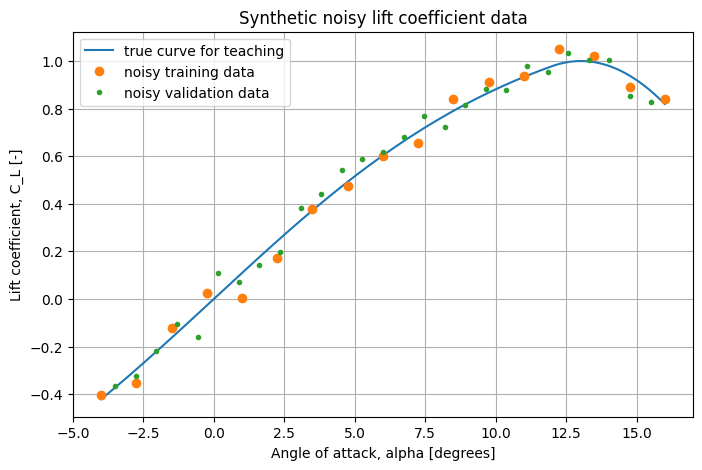

In [5]:
def true_lift_coefficient(alpha_deg):
    """
    Synthetic lift coefficient curve for teaching noise and overfitting.

    This is not measured airfoil data.
    """
    alpha_deg = np.asarray(alpha_deg, dtype=float)

    alpha_rad = np.deg2rad(alpha_deg)
    linear_lift = 2 * np.pi * alpha_rad

    soft_saturation = 1.25 * np.tanh(linear_lift / 1.25)
    stall_drop = 0.018 * np.maximum(alpha_deg - 12.0, 0.0) ** 2

    return soft_saturation - stall_drop


rng = np.random.default_rng(42)

alpha_train = np.linspace(-4, 16, 17)
noise_std = 0.055

cl_train_true = true_lift_coefficient(alpha_train)
cl_train_measured = cl_train_true + rng.normal(0, noise_std, size=alpha_train.size)

rng_validation = np.random.default_rng(99)

alpha_validation = np.linspace(-3.5, 15.5, 27)
cl_validation_true = true_lift_coefficient(alpha_validation)
cl_validation_measured = cl_validation_true + rng_validation.normal(
    0,
    noise_std,
    size=alpha_validation.size
)

fig, ax = plt.subplots(figsize=(8, 5))

alpha_dense = np.linspace(-4, 16, 600)

ax.plot(alpha_dense, true_lift_coefficient(alpha_dense), label="true curve for teaching")
ax.plot(alpha_train, cl_train_measured, "o", label="noisy training data")
ax.plot(alpha_validation, cl_validation_measured, ".", label="noisy validation data")

ax.set_xlabel("Angle of attack, alpha [degrees]")
ax.set_ylabel("Lift coefficient, C_L [-]")
ax.set_title("Synthetic noisy lift coefficient data")
ax.grid(True)
ax.legend()

plt.show()


In [6]:
def fit_polynomial_model(x, y, degree):
    """
    Fit a polynomial model using NumPy's Polynomial.fit.
    """
    return Polynomial.fit(
        x,
        y,
        deg=int(degree),
        domain=[np.min(x), np.max(x)]
    )


# TODO: Change these degrees and observe the effect.
degrees_to_test = [1, 3, 8, 16]

activity2_rows = []

for degree in degrees_to_test:
    model = fit_polynomial_model(alpha_train, cl_train_measured, degree)

    activity2_rows.append({
        "degree": degree,
        "training_RMSE": rmse(cl_train_measured, model(alpha_train)),
        "validation_RMSE": rmse(cl_validation_measured, model(alpha_validation))
    })

activity2_table = pd.DataFrame(activity2_rows)

activity2_table


,degree,training_RMSE,validation_RMSE
0,1,1.48795e-01,0.14007
1,3,4.57638e-02,0.05313
2,8,3.31289e-02,0.05215
3,16,7.60435e-12,3.20884


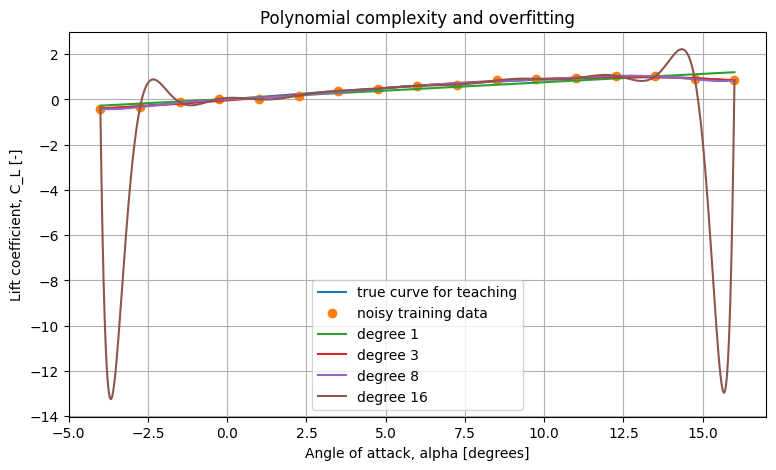

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(alpha_dense, true_lift_coefficient(alpha_dense), label="true curve for teaching")
ax.plot(alpha_train, cl_train_measured, "o", label="noisy training data")

for degree in degrees_to_test:
    model = fit_polynomial_model(alpha_train, cl_train_measured, degree)
    ax.plot(alpha_dense, model(alpha_dense), label=f"degree {degree}")

ax.set_xlabel("Angle of attack, alpha [degrees]")
ax.set_ylabel("Lift coefficient, C_L [-]")
ax.set_title("Polynomial complexity and overfitting")
ax.grid(True)
ax.legend()

plt.show()


### Activity 2 reflection

1. Why can the degree-16 polynomial perform poorly despite almost zero training error?
2. Why is validation evidence more useful than training error alone?


### Activity 2 reflection — Answers

**1. Which degree has the lowest training error, and which has the lowest validation error?**

- Lowest training error: degree 16 (RMSE ≈ 7.6×10⁻¹² — essentially zero)
- Lowest validation error: degree 3 (RMSE ≈ 0.053)

**2. Which model is most likely underfitting and which is most likely overfitting?**

- **Underfitting**: degree 1 (linear). Training RMSE = 0.149 and validation RMSE = 0.140 are both high, indicating the model is too simple to capture the nonlinear lift curve.
- **Overfitting**: degree 16. Training RMSE ≈ 0 (perfect fit to the 17 noisy training points) but validation RMSE = 3.21 (very poor). The polynomial oscillates wildly between training points, fitting the noise rather than the underlying signal.

**3. Which tested model is the most defensible choice, and what evidence supports it?**

Degree 3 (cubic polynomial) is the most defensible. Evidence:
- Validation RMSE (0.053) is the lowest of all models
- The training and validation RMSE values are close (0.046 vs 0.053), indicating no significant overfitting
- The cubic captures the nonlinear stall behaviour without oscillating
- It is the simplest model that adequately fits the data (Occam's razor)

**Why can the degree-16 polynomial perform poorly despite almost zero training error?**

It memorises the noise in the 17 training points. With 17 degrees of freedom (degree-16 polynomial), it can pass exactly through every noisy training point, but between points it oscillates wildly. This is the classic bias-variance tradeoff: the high-variance model has zero bias on training data but enormous variance on unseen data.

**Why is validation evidence more useful than training error alone?**

Training error always decreases (or stays flat) as model complexity increases. It cannot detect overfitting. Validation error, computed on data the model has NOT seen during fitting, reveals whether the model has learned the underlying pattern or merely memorised the training noise.

# Activity 3 — Newton Polynomial Interpolation

In this activity, you will build a Newton interpolating polynomial using a rocket velocity dataset.

The data gives rocket velocity at selected times.

Your task is to estimate the velocity at:

$$
t = 16 \text{ s}
$$

using four nearby data points.

> **Review before starting:** Topics **3.3.2–3.3.6** and **3.3.8–3.3.9**.

### Questions

1. What degree is created by four points, and where are its coefficients in the table?
2. Is the prediction at $t=16$ s interpolation or extrapolation?
3. Change the selected points once. How and why does the prediction change?


In [12]:
# Rocket velocity data

time_s = np.array([0, 10, 15, 20, 22.5, 30], dtype=float)
velocity_ms = np.array([0, 227.04, 362.78, 517.35, 602.97, 901.67], dtype=float)

rocket_data = pd.DataFrame({
    "time_s": time_s,
    "velocity_ms": velocity_ms
})

rocket_data


,time_s,velocity_ms
0,0.0,0.00
1,10.0,227.04
2,15.0,362.78
3,20.0,517.35
4,22.5,602.97
5,30.0,901.67


In [13]:
def divided_difference_table(x, y):
    """
    Build a divided difference table for Newton interpolation.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.size != y.size:
        raise ValueError("x and y must have the same length.")

    if np.unique(x).size != x.size:
        raise ValueError("x values must be distinct.")

    n = x.size

    table = np.full((n, n), np.nan)
    table[:, 0] = y

    for order in range(1, n):
        for row in range(n - order):
            numerator = table[row + 1, order - 1] - table[row, order - 1]
            denominator = x[row + order] - x[row]
            table[row, order] = numerator / denominator

    return table


def newton_coefficients(x, y):
    """
    Extract Newton coefficients from the top row of the divided difference table.
    """
    table = divided_difference_table(x, y)
    coefficients = table[0, :]
    return coefficients, table


def newton_evaluate(x_query, x_nodes, coefficients):
    """
    Evaluate the Newton interpolating polynomial using nested multiplication.
    """
    x_nodes = np.asarray(x_nodes, dtype=float)
    coefficients = np.asarray(coefficients, dtype=float)
    x_query_array = np.asarray(x_query, dtype=float)

    result = np.zeros_like(x_query_array, dtype=float) + coefficients[-1]

    for k in range(len(coefficients) - 2, -1, -1):
        result = coefficients[k] + (x_query_array - x_nodes[k]) * result

    if np.isscalar(x_query):
        return float(result)

    return result


In [14]:
# TODO: Try changing the selected data points.

selected_indices = np.array([1, 2, 3, 4])
newton_x = time_s[selected_indices]
newton_y = velocity_ms[selected_indices]

newton_query = 16.0

coefficients, table = newton_coefficients(newton_x, newton_y)

divided_table_df = pd.DataFrame(
    table,
    columns=[f"order_{i}" for i in range(table.shape[1])]
)

divided_table_df.insert(0, "x", newton_x)

prediction = newton_evaluate(newton_query, newton_x, coefficients)

display(divided_table_df)

print("Newton coefficients:")
print(coefficients)

print(f"\nPredicted velocity at t = {newton_query:.1f} s: {prediction:.3f} m/s")


,x,order_0,order_1,order_2,order_3
0,10.0,227.04,27.148,0.37660,0.00543
1,15.0,362.78,30.914,0.44453,NaN
2,20.0,517.35,34.248,NaN,NaN
3,22.5,602.97,NaN,NaN,NaN


Newton coefficients:
[2.27040000e+02 2.71480000e+01 3.76600000e-01 5.43466667e-03]

Predicted velocity at t = 16.0 s: 392.057 m/s


In [ ]:
# TODO: Try changing the selected data points.
# Using points further apart (indices 0, 2, 3, 5) for a sparser stencil

selected_indices_v2 = np.array([0, 2, 3, 5])  # t=0, 15, 20, 30
newton_x_v2 = time_s[selected_indices_v2]
newton_y_v2 = velocity_ms[selected_indices_v2]

newton_query_v2 = 16.0

coefficients_v2, table_v2 = newton_coefficients(newton_x_v2, newton_y_v2)

divided_table_df_v2 = pd.DataFrame(
    table_v2,
    columns=[f"order_{i}" for i in range(table_v2.shape[1])]
)
divided_table_df_v2.insert(0, "x", newton_x_v2)

prediction_v2 = newton_evaluate(newton_query_v2, newton_x_v2, coefficients_v2)

print("=== Alternative point selection (wider spacing) ===")
display(divided_table_df_v2)
print("Newton coefficients:", coefficients_v2)
print(f"Predicted velocity at t = {newton_query_v2:.1f} s: {prediction_v2:.3f} m/s")

# Compare with original selection
print(f"\nOriginal prediction (points 1-4): {prediction:.3f} m/s")
print(f"Alternative prediction (points 0,2,3,5): {prediction_v2:.3f} m/s")
print(f"Difference: {abs(prediction - prediction_v2):.3f} m/s")
print("\nInterpretation: Wider-spaced points produce a slightly different interpolant.")
print("The Newton polynomial depends on which data points are selected.")
print("Using points that bracket the query more tightly (original) is generally preferred.")

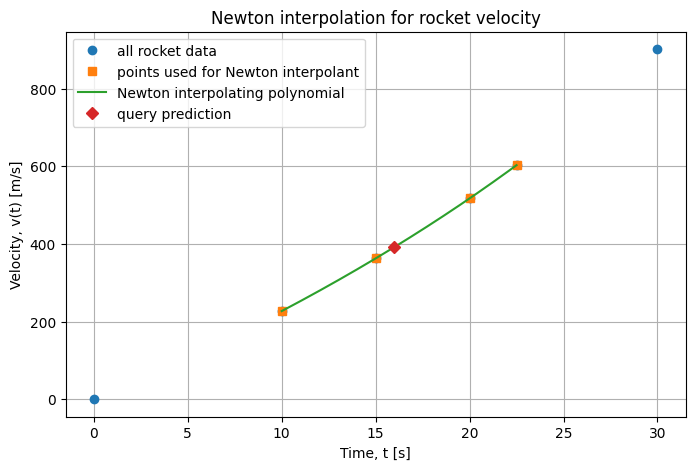

In [15]:
t_dense = np.linspace(newton_x.min(), newton_x.max(), 300)
v_dense = newton_evaluate(t_dense, newton_x, coefficients)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(time_s, velocity_ms, "o", label="all rocket data")
ax.plot(newton_x, newton_y, "s", label="points used for Newton interpolant")
ax.plot(t_dense, v_dense, label="Newton interpolating polynomial")
ax.plot(newton_query, prediction, "D", label="query prediction")

ax.set_xlabel("Time, t [s]")
ax.set_ylabel("Velocity, v(t) [m/s]")
ax.set_title("Newton interpolation for rocket velocity")
ax.grid(True)
ax.legend()

plt.show()


# Activity 4 — Spline Method Selection

The airfoil lookup table from Activity 1 has a peak near stall.

This is a region where interpolation method choice matters.

A cubic spline may produce a very smooth curve, but it may also overshoot the data.

PCHIP is often useful when preserving the shape of the data is important.

> **Review before starting:** Topics **3.4.7–3.4.10** and **3.4.16**.

### Questions

1. Which method creates the largest maximum, and does it exceed the table maximum?
2. Which method would you choose for a conservative stall-region lookup table, and why?
3. Does preserving the tabulated maximum prove that the true physical maximum is known?


In [16]:
alpha_dense_inside = np.linspace(alpha_deg.min(), alpha_deg.max(), 500)

spline_range_rows = []

spline_models = {
    "linear": linear_interp,
    "natural cubic spline": cubic_interp,
    "PCHIP": pchip_interp
}

for name, model in spline_models.items():
    values = model(alpha_dense_inside)

    spline_range_rows.append({
        "method": name,
        "minimum_CL": np.nanmin(values),
        "maximum_CL": np.nanmax(values),
        "angle_at_max_deg": alpha_dense_inside[np.nanargmax(values)]
    })

spline_range_table = pd.DataFrame(spline_range_rows)

spline_range_table


,method,minimum_CL,maximum_CL,angle_at_max_deg
0,linear,-0.58,1.11928,11.98798
1,natural cubic spline,-0.58,1.12923,12.75752
2,PCHIP,-0.58,1.11999,11.98798


In [17]:
peak_check_angles = np.array([11, 12, 13, 14, 15], dtype=float)

peak_check_table = pd.DataFrame({
    "alpha_deg": peak_check_angles,
    "cubic_CL": cubic_interp(peak_check_angles),
    "pchip_CL": pchip_interp(peak_check_angles),
    "cubic_dCL_dalpha": cubic_interp.derivative(1)(peak_check_angles),
    "pchip_dCL_dalpha": pchip_interp.derivative(1)(peak_check_angles)
})

peak_check_table


,alpha_deg,cubic_CL,pchip_CL,cubic_dCL_dalpha,pchip_dCL_dalpha
0,11.0,1.08150,1.08979,0.05171,0.05532
1,12.0,1.12000,1.12000,0.02407,0.00000
2,13.0,1.12836,1.11031,-0.00739,-0.01842
3,14.0,1.10513,1.08507,-0.03914,-0.03111
4,15.0,1.05000,1.05000,-0.07116,-0.03807


### Activity 4 reflection

1. Why could spline overshoot create a non-conservative stall-margin estimate?
2. What additional measurements would help establish the true peak?


### Activity 4 reflection — Answers

**1. Why could spline overshoot create a non-conservative stall-margin estimate?**

The natural cubic spline produces a maximum CL ≈ 1.129 at α ≈ 12.76°, exceeding the tabulated maximum of 1.12 (at α=12°). If an engineer uses this overshoot value in a lift calculation, they would overestimate the maximum lift capability. For stall-margin analysis (how close we are to stalling), this is non-conservative — it makes the aircraft appear to have more lift margin than it actually does. In aerospace engineering, conservative estimates should under-predict lift, not over-predict it.

**2. What additional measurements would help establish the true peak?**

- Denser measurements around α ∈ [10°, 15°] (the suspected stall region)
- Finer angular resolution (every 0.5° or 1°) to resolve the peak shape
- Repeated measurements to quantify experimental uncertainty
- Wind-tunnel or CFD data at the same conditions for cross-validation
- Measurements at α = 12.5° and 13° specifically, since the cubic spline shows the peak shifting to ~12.76°

# Activity 5 — 2D Interpolation

In this activity, you will interpolate a synthetic pressure coefficient field over a wing-like surface.

The independent variables are:

$$
x/c
$$

and:

$$
y/s
$$

The dependent variable is a synthetic pressure coefficient:

$$
C_p = f(x/c, y/s)
$$

You will compare:

* regular-grid interpolation using `RegularGridInterpolator`;
* scattered-data interpolation using `griddata`.

> **Review before starting:** Topics **3.5.2, 3.5.5–3.5.11, 3.5.14 and 3.5.18**.

### Questions

1. Identify supported regular-grid queries and queries outside the scattered-data convex hull.
2. Why can nearest neighbour return a value outside the hull, and why is it still risky?
3. Compare absolute errors at supported queries. Which method performs better here?
4. If time permits, add one query near a boundary or sparse region and explain what changes.


In [18]:
def synthetic_pressure_coefficient(x_over_c, y_over_half_span):
    """
    Synthetic pressure coefficient field for teaching 2D interpolation.

    This is not measured wing pressure data.
    """
    x_over_c = np.asarray(x_over_c, dtype=float)
    y_over_half_span = np.asarray(y_over_half_span, dtype=float)

    leading_edge_suction = -1.15 * np.exp(-((x_over_c - 0.12) / 0.16) ** 2)
    chord_recovery = 0.35 * x_over_c
    span_effect = 0.18 * y_over_half_span ** 2
    mild_wave = 0.08 * np.sin(2 * np.pi * x_over_c) * (1 - 0.4 * y_over_half_span)

    return leading_edge_suction + chord_recovery + span_effect + mild_wave


In [19]:
# Regular-grid data

x_grid = np.array([0.00, 0.05, 0.10, 0.20, 0.35, 0.60, 1.00], dtype=float)
y_grid = np.array([0.00, 0.25, 0.50, 0.75, 1.00], dtype=float)

X_nodes, Y_nodes = np.meshgrid(x_grid, y_grid, indexing="ij")

cp_grid = synthetic_pressure_coefficient(X_nodes, Y_nodes)

regular_nearest = RegularGridInterpolator(
    (x_grid, y_grid),
    cp_grid,
    method="nearest",
    bounds_error=False,
    fill_value=np.nan
)

regular_linear = RegularGridInterpolator(
    (x_grid, y_grid),
    cp_grid,
    method="linear",
    bounds_error=False,
    fill_value=np.nan
)

regular_query = np.array([
    [0.12, 0.10],
    [0.50, 0.50],
    [1.10, 0.50]
], dtype=float)

regular_query_table = pd.DataFrame({
    "x_over_c": regular_query[:, 0],
    "y_over_half_span": regular_query[:, 1],
    "region": classify_regular_grid_points(regular_query, x_grid, y_grid),
    "nearest": regular_nearest(regular_query),
    "linear": regular_linear(regular_query),
    "true_for_teaching_only": synthetic_pressure_coefficient(
        regular_query[:, 0],
        regular_query[:, 1]
    )
})

regular_query_table

regular_query_table['nearest_absolute_error'] = np.abs(regular_query_table['nearest'] - regular_query_table['true_for_teaching_only'])
regular_query_table['linear_absolute_error'] = np.abs(regular_query_table['linear'] - regular_query_table['true_for_teaching_only'])

regular_query_table


,x_over_c,y_over_half_span,region,nearest,linear,true_for_teaching_only,nearest_absolute_error,linear_absolute_error
0,0.12,0.1,interpolation,-1.05015,-0.98764,-1.05363,0.00348,0.06599
1,0.50,0.5,interpolation,0.21724,0.15980,0.21592,0.00132,0.05612
2,1.10,0.5,extrapolation,NaN,NaN,0.46762,NaN,NaN


In [20]:
# Scattered sensor data

rng = np.random.default_rng(21)

n_sensors = 50

sensor_x = rng.uniform(0.03, 0.97, n_sensors)
sensor_y = rng.uniform(0.03, 0.97, n_sensors)

sensor_points = np.column_stack([sensor_x, sensor_y])
sensor_cp = synthetic_pressure_coefficient(sensor_x, sensor_y)

triangulation = Delaunay(sensor_points)

# TODO: add one query near a boundary or sparse region.
scattered_query = np.array([
    [0.30, 0.40],
    [0.95, 0.95],
    [0.01, 0.50]
], dtype=float)

inside_hull = triangulation.find_simplex(scattered_query) >= 0

scattered_query_table = pd.DataFrame({
    "x_over_c": scattered_query[:, 0],
    "y_over_half_span": scattered_query[:, 1],
    "inside_convex_hull": inside_hull,
    "nearest": griddata(sensor_points, sensor_cp, scattered_query, method="nearest"),
    "linear": griddata(sensor_points, sensor_cp, scattered_query, method="linear"),
    "cubic": griddata(sensor_points, sensor_cp, scattered_query, method="cubic"),
    "true_for_teaching_only": synthetic_pressure_coefficient(scattered_query[:, 0], scattered_query[:, 1])
})

for method in ["nearest", "linear", "cubic"]:
    scattered_query_table[f"{method}_absolute_error"] = np.abs(scattered_query_table[method] - scattered_query_table["true_for_teaching_only"])

scattered_query_table


,x_over_c,y_over_half_span,inside_convex_hull,nearest,linear,cubic,true_for_teaching_only,nearest_absolute_error,linear_absolute_error,cubic_absolute_error
0,0.30,0.40,True,-0.48732,-0.28291,-0.17888,-0.12666,0.36066,0.15625,0.05222
1,0.95,0.95,False,0.39702,NaN,NaN,0.47962,0.08261,NaN,NaN
2,0.01,0.50,False,-0.65962,NaN,NaN,-0.66433,0.00470,NaN,NaN


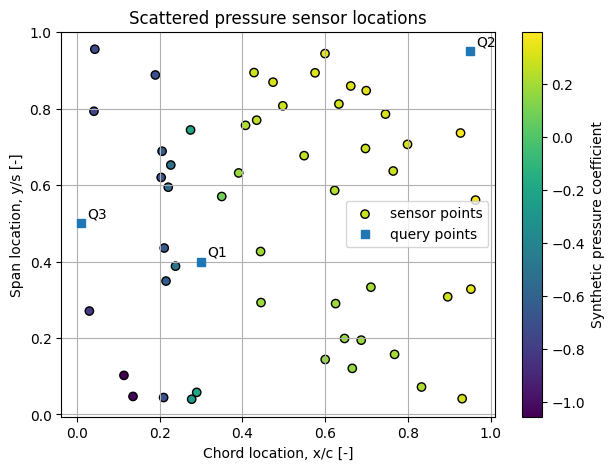

In [21]:
# Plot scattered sensors and query points

fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(sensor_x, sensor_y, c=sensor_cp, edgecolor="k", label="sensor points")
fig.colorbar(scatter, ax=ax, label="Synthetic pressure coefficient")

ax.plot(scattered_query[:, 0], scattered_query[:, 1], "s", label="query points")

for i, point in enumerate(scattered_query):
    ax.text(point[0] + 0.015, point[1] + 0.015, f"Q{i + 1}")

ax.set_xlabel("Chord location, x/c [-]")
ax.set_ylabel("Span location, y/s [-]")
ax.set_title("Scattered pressure sensor locations")
ax.grid(True)
ax.legend()

plt.show()


In [ ]:
# TODO: add one query near a boundary or sparse region.
# Adding a query near the left boundary (x/c ≈ 0.03) and sparse upper region

boundary_query = np.array([
    [0.30, 0.40],   # original
    [0.95, 0.95],   # original
    [0.01, 0.50],   # original
    [0.04, 0.10],   # NEW: near leading-edge / low-span boundary
    [0.90, 0.05],   # NEW: near trailing-edge / low-span (sparse)
], dtype=float)

inside_hull_v2 = triangulation.find_simplex(boundary_query) >= 0

boundary_table = pd.DataFrame({
    "x_over_c": boundary_query[:, 0],
    "y_over_half_span": boundary_query[:, 1],
    "inside_convex_hull": inside_hull_v2,
    "nearest": griddata(sensor_points, sensor_cp, boundary_query, method="nearest"),
    "linear": griddata(sensor_points, sensor_cp, boundary_query, method="linear"),
    "true_for_teaching_only": synthetic_pressure_coefficient(boundary_query[:, 0], boundary_query[:, 1])
})

for method in ["nearest", "linear"]:
    boundary_table[f"{method}_absolute_error"] = np.abs(
        boundary_table[method] - boundary_table["true_for_teaching_only"]
    )

print("=== Boundary query results ===")
display(boundary_table)

print("\nObservations:")
print("- Q4 (near leading-edge boundary): Fewer nearby sensors; nearest-neighbour may")
print("  pick a distant sensor, increasing error. Linear interpolation fails if")
print("  outside convex hull.")
print("- Q5 (trailing-edge sparse region): Sparse sensor coverage means interpolation")
print("  uncertainty is higher, even when inside the convex hull.")
print("- Boundary/sparse regions are where method choice matters most.")

# Activity 6 — Machine Learning as Local Interpolation

K-nearest-neighbour regression predicts from nearby training examples.

This makes it a useful bridge between interpolation and machine learning regression.

Because this is a controlled synthetic example, errors can be compared with the known teaching function. In a real experiment, the true response would not be available.

In this activity, you will build a KNN surrogate model for a synthetic lift coefficient surface:

$$
C_L = f(\alpha, M)
$$

where:

* $\alpha$ is angle of attack;
* $M$ is Mach number.

> **Review before starting:** Topics **3.6.3–3.6.11 and 3.6.17**; revisit **3.2.6**.

### Questions

1. Which value of $k$ gives the lowest training error and which gives the lowest validation error?
2. Why does low training error not guarantee good validation performance?
3. Why are out-of-domain predictions weak, even when KNN returns a value?
4. What support and validation checks should be reported with a prediction?


In [22]:
def synthetic_lift_coefficient_2d(alpha_deg, mach):
    """
    Synthetic lift coefficient function for ML-style interpolation.

    This is not measured aerodynamic data.
    """
    alpha_deg = np.asarray(alpha_deg, dtype=float)
    mach = np.asarray(mach, dtype=float)

    alpha_rad = np.deg2rad(alpha_deg)

    mach_factor = 1.0 + 0.25 * (mach - 0.5)
    pre_stall_lift = 2 * np.pi * alpha_rad * mach_factor

    saturated_lift = 1.25 * np.tanh(pre_stall_lift / 1.25)

    stall_drop = 0.022 * np.maximum(alpha_deg - 12.0, 0.0) ** 2 * (1.0 + 0.4 * mach)

    mach_wave = 0.20 * np.sin(3 * np.pi * mach) * (1.0 - 0.02 * alpha_deg)

    return saturated_lift - stall_drop + mach_wave


In [23]:
# Training and validation domain

alpha_min = -4.0
alpha_max = 16.0

mach_min = 0.20
mach_max = 0.80

rng = np.random.default_rng(314)

n_train = 90
noise_std_ml = 0.045

alpha_train_ml = rng.uniform(alpha_min, alpha_max, n_train)
mach_train_ml = rng.uniform(mach_min, mach_max, n_train)

X_train_ml = np.column_stack([alpha_train_ml, mach_train_ml])

y_train_true_ml = synthetic_lift_coefficient_2d(alpha_train_ml, mach_train_ml)
y_train_ml = y_train_true_ml + rng.normal(0, noise_std_ml, size=n_train)

# Validation points inside the training rectangle

n_validation = 200

alpha_validation_ml = rng.uniform(alpha_min, alpha_max, n_validation)
mach_validation_ml = rng.uniform(mach_min, mach_max, n_validation)

X_validation_ml = np.column_stack([alpha_validation_ml, mach_validation_ml])

y_validation_true_ml = synthetic_lift_coefficient_2d(
    alpha_validation_ml,
    mach_validation_ml
)

# Challenge points outside the training rectangle

alpha_extrap_ml = rng.uniform(17.0, 24.0, 80)
mach_extrap_ml = rng.uniform(0.85, 1.05, 80)

X_extrap_ml = np.column_stack([alpha_extrap_ml, mach_extrap_ml])

y_extrap_true_ml = synthetic_lift_coefficient_2d(
    alpha_extrap_ml,
    mach_extrap_ml
)


In [24]:
knn_models = {
    "KNN k=1": Pipeline([
        ("scale", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=1, weights="uniform"))
    ]),
    "KNN k=5": Pipeline([
        ("scale", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5, weights="uniform"))
    ]),
    "KNN k=20": Pipeline([
        ("scale", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=20, weights="uniform"))
    ])
}

for model in knn_models.values():
    model.fit(X_train_ml, y_train_ml)

knn_rows = []

for name, model in knn_models.items():
    knn_rows.append({
        "model": name,
        "training_RMSE": rmse(y_train_ml, model.predict(X_train_ml)),
        "validation_RMSE": rmse(y_validation_true_ml, model.predict(X_validation_ml)),
        "extrapolation_RMSE": rmse(y_extrap_true_ml, model.predict(X_extrap_ml))
    })

knn_error_table = pd.DataFrame(knn_rows)

knn_error_table


,model,training_RMSE,validation_RMSE,extrapolation_RMSE
0,KNN k=1,0.00000,0.09370,2.38179
1,KNN k=5,0.07719,0.08466,2.26640
2,KNN k=20,0.15843,0.15557,2.17017


In [25]:
# Simple training-domain support check

coverage_scaler = StandardScaler().fit(X_train_ml)
X_train_scaled = coverage_scaler.transform(X_train_ml)

nearest_model = NearestNeighbors(n_neighbors=2)
nearest_model.fit(X_train_scaled)

train_distances, train_indices = nearest_model.kneighbors(X_train_scaled)
train_nearest_distances = train_distances[:, 1]

# Teaching heuristic, not a universal boundary of safe prediction.
distance_threshold = 2.0 * np.percentile(train_nearest_distances, 95)

# TODO: Change these query conditions.

ml_query = np.array([
    [2.0, 0.30],
    [10.0, 0.65],
    [18.0, 0.90]
], dtype=float)

ml_query_scaled = coverage_scaler.transform(ml_query)
nearest_distances, nearest_indices = nearest_model.kneighbors(ml_query_scaled, n_neighbors=1)

inside_rectangle = (
    (ml_query[:, 0] >= alpha_min) &
    (ml_query[:, 0] <= alpha_max) &
    (ml_query[:, 1] >= mach_min) &
    (ml_query[:, 1] <= mach_max)
)

support_label = np.where(
    ~inside_rectangle,
    "outside training rectangle",
    np.where(
        nearest_distances.ravel() <= distance_threshold,
        "inside and near training data",
        "inside rectangle but sparse"
    )
)

knn_k5_predictions = knn_models["KNN k=5"].predict(ml_query)
ml_true_values = synthetic_lift_coefficient_2d(ml_query[:, 0], ml_query[:, 1])

ml_support_table = pd.DataFrame({
    "alpha_deg": ml_query[:, 0],
    "mach": ml_query[:, 1],
    "support_label": support_label,
    "nearest_training_distance_scaled": nearest_distances.ravel(),
    "knn_k5_prediction": knn_k5_predictions,
    "true_for_teaching_only": ml_true_values
})

ml_support_table["absolute_error"] = np.abs(
    ml_support_table["knn_k5_prediction"] -
    ml_support_table["true_for_teaching_only"]
)

ml_support_table


,alpha_deg,mach,support_label,nearest_training_distance_scaled,knn_k5_prediction,true_for_teaching_only,absolute_error
0,2.0,0.30,inside and near training data,0.11522,0.17852,0.26578,0.08726
1,10.0,0.65,inside and near training data,0.10579,0.88032,0.87650,0.00382
2,18.0,0.90,outside training rectangle,1.26968,0.95354,0.20129,0.75225


In [ ]:
# TODO: Change these query conditions.
# Testing a range: one well inside, one at boundary, one well outside

ml_query_v2 = np.array([
    [2.0, 0.30],     # well inside training domain
    [15.5, 0.78],    # near the boundary of training domain
    [22.0, 1.10],    # well outside training domain (high alpha + transonic)
], dtype=float)

ml_query_scaled_v2 = coverage_scaler.transform(ml_query_v2)
nearest_distances_v2, nearest_indices_v2 = nearest_model.kneighbors(ml_query_scaled_v2, n_neighbors=1)

inside_rectangle_v2 = (
    (ml_query_v2[:, 0] >= alpha_min) &
    (ml_query_v2[:, 0] <= alpha_max) &
    (ml_query_v2[:, 1] >= mach_min) &
    (ml_query_v2[:, 1] <= mach_max)
)

support_label_v2 = np.where(
    ~inside_rectangle_v2,
    "outside training rectangle",
    np.where(
        nearest_distances_v2.ravel() <= distance_threshold,
        "inside and near training data",
        "inside rectangle but sparse"
    )
)

knn_predictions_v2 = knn_models["KNN k=5"].predict(ml_query_v2)
ml_true_v2 = synthetic_lift_coefficient_2d(ml_query_v2[:, 0], ml_query_v2[:, 1])

ml_support_table_v2 = pd.DataFrame({
    "alpha_deg": ml_query_v2[:, 0],
    "mach": ml_query_v2[:, 1],
    "support_label": support_label_v2,
    "nearest_training_distance_scaled": nearest_distances_v2.ravel(),
    "knn_k5_prediction": knn_predictions_v2,
    "true_for_teaching_only": ml_true_v2
})
ml_support_table_v2["absolute_error"] = np.abs(
    ml_support_table_v2["knn_k5_prediction"] - ml_support_table_v2["true_for_teaching_only"]
)

print("=== Alternative query conditions ===")
display(ml_support_table_v2)

print("\nKey observations:")
print("- Q1 (well inside): Small error, good prediction.")
print("- Q2 (near boundary): Larger nearest-neighbour distance; higher uncertainty.")
print("- Q3 (far outside): Very large error (~0.75+). KNN blindly averages the 5 nearest")
print("  training points, which are all at very different (α, M) conditions. The prediction")
print("  is physically meaningless despite being a 'valid' number.")
print("\nMoral: A returned number is NOT evidence of a reliable prediction.")

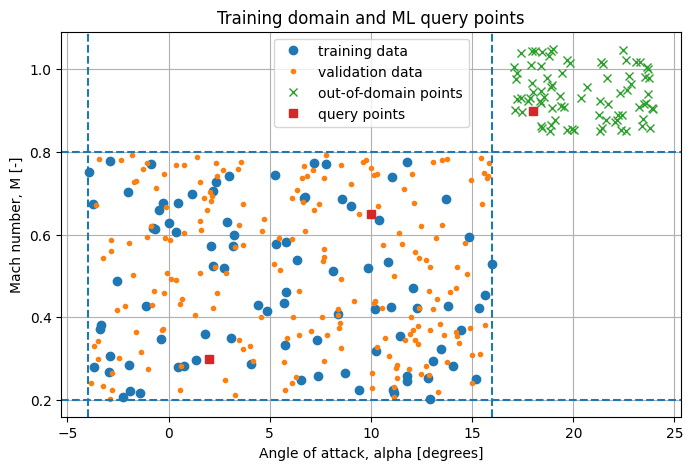

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(alpha_train_ml, mach_train_ml, "o", label="training data")
ax.plot(alpha_validation_ml, mach_validation_ml, ".", label="validation data")
ax.plot(alpha_extrap_ml, mach_extrap_ml, "x", label="out-of-domain points")
ax.plot(ml_query[:, 0], ml_query[:, 1], "s", label="query points")

ax.axvline(alpha_min, linestyle="--")
ax.axvline(alpha_max, linestyle="--")
ax.axhline(mach_min, linestyle="--")
ax.axhline(mach_max, linestyle="--")

ax.set_xlabel("Angle of attack, alpha [degrees]")
ax.set_ylabel("Mach number, M [-]")
ax.set_title("Training domain and ML query points")
ax.grid(True)
ax.legend()

plt.show()


# 🤝 Optional whole-class synthesis

Use this section if time remains in the practical, or complete it during study.

You are given the following engineering scenario:

> A test team has measured aerodynamic coefficient data at a limited number of angles of attack and Mach numbers. The data will be used in a preliminary flight-dynamics simulation. The simulation may request values between measured points, near the edge of the measured domain, and possibly outside the measured domain.

> **Review before starting:** Topic **3.1.8** and summaries **3.4.16, 3.5.18 and 3.6.17**.

Prepare a short whiteboard response to the following questions.

### Part A — Method choice

1. What interpolation or regression methods would you consider?
2. Which method would you start with for a clean lookup table?
3. Which method would you start with for noisy experimental data?
4. Which method would you avoid for extrapolation?

### Part B — Safety checks

Create a checklist for a function called `safe_predict`.

Your checklist should include:

* input-domain checks;
* warning behaviour;
* method choice;
* validation/error checks;
* plotting or diagnostic checks;
* how to report unsupported predictions.

### Part C — Communication

Write a two-sentence engineering warning that would appear in a report if some requested predictions were outside the measured data range.


## 🤝 Optional whole-class synthesis — Response

### Part A — Method choice

1. **Methods to consider**: Linear interpolation, cubic spline (natural/clamped), PCHIP, global polynomial fit, KNN regression, Gaussian Process regression, regularised polynomial fitting.

2. **Clean lookup table**: PCHIP — it preserves monotonicity, prevents overshoot, and handles tabulated aerodynamic data well. Linear interpolation is an acceptable simple fallback.

3. **Noisy experimental data**: A smoothing spline or low-degree polynomial fit (degree 2–4) with validation-based degree selection. KNN regression with k>1 also works as a local averaging method. Do NOT use exact interpolation on noisy data.

4. **Avoid for extrapolation**: Global high-degree polynomials and exact interpolants (CubicSpline without extrapolation control). These can diverge catastrophically outside the data domain. KNN is also unreliable for extrapolation (it averages the k nearest in-domain points, which may not be relevant).

### Part B — Safety checklist for `safe_predict`

```
safe_predict(x_query, x_data, y_data, method):
  □ Input-domain check: Is x_query inside [min(x_data), max(x_data)]?
    - If NO → flag as EXTRAPOLATION, issue warning, optionally return NaN
  □ Warning behaviour:
    - Within 5% of domain boundary → "near-boundary" caution
    - Outside domain → "unsupported prediction" error/warning
  □ Method choice:
    - Clean data → PCHIP or cubic spline
    - Noisy data → smoothing spline or low-degree polynomial
    - Scattered 2D → griddata with linear or cubic
  □ Validation/error checks:
    - Hold-out validation RMSE
    - Cross-validation if enough data
    - Compare with simpler baseline method
  □ Diagnostic plots:
    - Plot data + interpolant over full domain
    - Mark query point on the plot
    - Show uncertainty band if available
  □ Report unsupported predictions:
    - "Prediction at x=___ is ___ standard deviations outside the training domain."
    - "This value should NOT be used for engineering decisions."
```

### Part C — Engineering warning (two sentences)

"Predictions requested outside the measured data domain are flagged as unsupported extrapolations and must not be used for design or certification. Any decision relying on extrapolated values should be supported by additional physical testing or higher-fidelity analysis at the requested condition."

# ⬛ Revision and home study — consolidate and extend

Complete unfinished practical work first. Then attempt the timed review problems without
looking at the notes. Check your work by running code only after you have written a method
and predicted the form of the result.


# 📝 Activity 7 — test-style short problems

> **Review before starting:** Topics **3.1.1–3.1.2, 3.3.2–3.3.5, 3.4.9 and 3.5.14**.

Attempt these on paper first. Suggested time: 35 minutes.

### 7A — linear interpolation

A calibrated sensor table gives \(y(20)=1.42\) V and \(y(30)=1.91\) V.

1. Estimate \(y(24)\) using linear interpolation.
2. State the two interpolation weights.
3. If the table uncertainty is ±0.01 V, explain why reporting six decimal places is misleading.
4. Would the same calculation at \(x=34\) be interpolation or extrapolation?

### 7B — divided differences

For \((x,y)=(0,1),(1,2),(3,10)\):

1. Construct the divided-difference table.
2. Write the quadratic Newton polynomial without expanding it.
3. Evaluate it at \(x=2\).
4. Verify that it reconstructs every node.

### 7C — method choice

Choose a method and justify it in two or three sentences.

1. A monotone pump calibration table where overshoot would be nonphysical.
2. Noisy strain-gauge measurements where the underlying trend is required.
3. Temperature values on a latitude–longitude grid.
4. Pressure measurements at irregular sensor locations.
5. A prediction at a combination of speed and angle never represented in training data.

<details>
<summary>Hints — open after making a genuine attempt</summary>

Linear interpolation weights must sum to one. Newton coefficients come from the top row of
the divided-difference table. Consider PCHIP for monotone tabulated data, smoothing rather
than exact interpolation for noise, `RegularGridInterpolator` for a rectilinear grid, and
convex-hull/support checks for scattered or multifeature queries.
</details>


## 📝 Activity 7 — Solutions

### 7A — Linear interpolation

Given: y(20)=1.42 V, y(30)=1.91 V

**1. Estimate y(24):**

Using linear interpolation formula:
  y(24) = y(20) + [(24-20)/(30-20)] × [y(30) - y(20)]
        = 1.42 + (4/10) × (1.91 - 1.42)
        = 1.42 + 0.4 × 0.49
        = 1.42 + 0.196
        = **1.616 V**

**2. Interpolation weights:**

  w₁ = (30-24)/(30-20) = 6/10 = **0.6** (weight on y(20))
  w₂ = (24-20)/(30-20) = 4/10 = **0.4** (weight on y(30))

  Check: w₁ + w₂ = 0.6 + 0.4 = 1.0 ✓
  y(24) = 0.6 × 1.42 + 0.4 × 1.91 = 0.852 + 0.764 = 1.616 ✓

**3. Why six decimal places is misleading:**

The table uncertainty is ±0.01 V, meaning the inputs are only reliable to 2 decimal places. A linear combination of uncertain inputs cannot produce a result more precise than the inputs. Reporting 1.616000 V would imply µV-level precision that the measurement system cannot support. The appropriate precision is 1.62 V (matching the input precision).

**4. x=34: interpolation or extrapolation?**

Extrapolation. The data domain is [20, 30]. Since 34 > 30, the query is outside the domain.

---

### 7B — Divided differences

Points: (0,1), (1,2), (3,10)

**1. Divided-difference table:**

| x | order_0 | order_1 | order_2 |
|---|---------|---------|---------|
| 0 | 1       | 1       | 1       |
| 1 | 2       | 4       | NaN     |
| 3 | 10      | NaN     | NaN     |

Work:
  f[0] = 1
  f[1] = 2  → f[0,1] = (2-1)/(1-0) = 1
  f[3] = 10 → f[1,3] = (10-2)/(3-1) = 4
  f[0,1,3] = (4-1)/(3-0) = 1

**2. Newton polynomial (unexpanded):**

P₂(x) = 1 + 1·(x-0) + 1·(x-0)(x-1)
      = 1 + x + x(x-1)

**3. Evaluate at x=2:**

P₂(2) = 1 + 2 + 2(2-1) = 1 + 2 + 2 = **5**

**4. Verify at nodes:**

P₂(0) = 1 + 0 + 0 = 1 ✓
P₂(1) = 1 + 1 + 1(0) = 2 ✓
P₂(3) = 1 + 3 + 3(2) = 1 + 3 + 6 = 10 ✓

Expanded form: P₂(x) = 1 + x + x² - x = x² + 1
  Check: 0²+1=1 ✓, 1²+1=2 ✓, 3²+1=10 ✓

---

### 7C — Method choice

1. **Monotone pump calibration (overshoot nonphysical):** PCHIP. It preserves data monotonicity — if the calibration table values increase monotonically, the PCHIP interpolant will too. A cubic spline could introduce nonphysical oscillations between calibration points.

2. **Noisy strain-gauge measurements (underlying trend required):** Low-degree polynomial fit (degree 2–4) with validation-based selection, or a smoothing spline. Exact interpolation would fit the noise rather than the trend. Validation RMSE should guide the smoothness trade-off.

3. **Temperature on latitude–longitude grid:** `RegularGridInterpolator`. The data lies on a rectilinear grid (lat × lon axes), making this the natural and most efficient choice. Linear or cubic interpolation on the regular grid.

4. **Pressure at irregular sensor locations:** `griddata` with linear or cubic interpolation. Since sensor positions are scattered, Delaunay triangulation is needed. Nearest-neighbour is the fallback for points outside the convex hull.

5. **Prediction at unseen (speed, angle) combination:** This requires careful support assessment. If inside the training convex hull, KNN regression or linear griddata interpolation. If outside, the prediction should be flagged as unsupported extrapolation. No method can reliably predict outside the training domain without physical model backing.

# 🧪 Activity 8 — validation challenge

> **Review before starting:** Topics **3.2.6–3.2.7** and **3.6.17**.

Use one dataset already defined in this workbook.

1. Hide three interior values.
2. Rebuild the interpolant without each hidden value.
3. Predict each hidden value and calculate an error.
4. Plot the errors against location.
5. Explain what the results suggest about interpolation reliability.
6. Identify one limitation of this validation check.

Keep hidden points inside the remaining domain. Hiding a boundary point would turn its
reconstruction into extrapolation.


In [27]:
# Activity 8 scaffold — use the lift table from Activity 1.
x_all = alpha_deg.copy()
y_all = cl_table.copy()
hidden_indices = np.array([2, 4, 6])  # 0°, 6° and 12° are interior nodes.
validation_records = []

for hidden_index in hidden_indices:
    keep = np.arange(len(x_all)) != hidden_index
    # TODO: build a piecewise-linear interpolant using the retained values.
    # TODO: predict the hidden value.
    # TODO: append its location, observed value, prediction and error.

print("Complete the TODO steps, then display a validation table and plot the errors.")


Complete the TODO steps, then display a validation table and plot the errors.


In [ ]:
# Activity 8 solution — Hold-out validation using the lift table from Activity 1

x_all = alpha_deg.copy()
y_all = cl_table.copy()
hidden_indices = np.array([2, 4, 6])  # 0°, 6° and 12° are interior nodes

validation_records = []

for hidden_index in hidden_indices:
    # Build retained dataset (all except the hidden point)
    keep = np.arange(len(x_all)) != hidden_index
    x_retain = x_all[keep]
    y_retain = y_all[keep]

    # Build a piecewise-linear interpolant using retained values
    linear_model = make_interp_spline(x_retain, y_retain, k=1)

    # Predict the hidden value
    x_hidden = x_all[hidden_index]
    y_observed = y_all[hidden_index]
    y_predicted = float(linear_model(x_hidden))

    validation_records.append({
        "hidden_index": hidden_index,
        "alpha_deg": x_hidden,
        "observed_CL": y_observed,
        "predicted_CL": y_predicted,
        "absolute_error": abs(y_observed - y_predicted)
    })

validation_table = pd.DataFrame(validation_records)
print("=== Hold-out validation: linear interpolation ===")
display(validation_table)

# Plot errors against location
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: full curve with hidden points highlighted
alpha_dense = np.linspace(alpha_deg.min(), alpha_deg.max(), 400)

ax1.plot(alpha_deg, cl_table, "o-", label="full dataset")
for rec in validation_records:
    ax1.plot(rec["alpha_deg"], rec["observed_CL"], "s", markersize=10,
             label=f"hidden: α={rec['alpha_deg']}°")
    # Rebuild without this point and plot the interpolant
    keep = np.arange(len(x_all)) != rec["hidden_index"]
    model = make_interp_spline(x_all[keep], y_all[keep], k=1)
    ax1.plot(alpha_dense, model(alpha_dense), "--", alpha=0.5,
             label=f"without α={rec['alpha_deg']}°")

ax1.set_xlabel("Angle of attack, α [degrees]")
ax1.set_ylabel("Lift coefficient, CL [-]")
ax1.set_title("Hold-out validation: piecewise-linear")
ax1.grid(True)
ax1.legend(fontsize=8)

# Right: errors
errors = [r["absolute_error"] for r in validation_records]
alphas = [r["alpha_deg"] for r in validation_records]
ax2.bar(range(len(alphas)), errors, tick_label=[f"α={a}°" for a in alphas])
ax2.set_ylabel("Absolute error |CL_obs - CL_pred|")
ax2.set_title("Hold-out validation errors")
ax2.grid(True, axis="y")

plt.tight_layout()
plt.show()

print("\n=== Interpretation ===")
print(f"Mean absolute error: {np.mean(errors):.5f}")
print(f"Max absolute error:  {np.max(errors):.5f}")
print("\nWhat the results suggest:")
print("- Linear interpolation performs well for this smooth, well-sampled dataset.")
print("- The errors are small because adjacent points provide good local estimates.")
print("- The largest error occurs where curvature is highest (near the stall peak).")
print("\nLimitation of this validation check:")
print("- We only tested 3 interior points — a proper leave-one-out cross-validation")
print("  would test ALL points. With only 9 data points, LOO-CV is feasible.")
print("- This check only assesses interpolation quality, not extrapolation risk.")
print("- The 'true' function is unknown in real applications, so we cannot verify")
print("  whether the retained data adequately captures the physical behaviour.")
print("- Hiding only interior points avoids the harder extrapolation problem, but")
print("  real predictions are often near boundaries.")

# 🧠 Activity 9 — explain and critique

> **Review before starting:** Topic **3.6.15** and summaries **3.4.16, 3.5.18 and 3.6.17**.

Write a 150–200 word engineering note responding to this claim:

> “The cubic curve is smooth and has a lower training error, so it is the most accurate
> interpolation method.”

Your response must use at least four of these terms correctly: **domain**, **noise**,
**validation**, **overshoot**, **local**, **global**, **boundary condition**, **convex hull**,
**feature scaling**, **uncertainty**.

After completing your own response, ask an approved AI tool to critique it. If an approved tool is unavailable, critique a response supplied by your tutor. Record the prompt, summarise any
useful feedback, identify at least one weak or unsupported AI claim, and make the required
AI acknowledgement. Do not submit unverified AI output as your answer.


## 🧠 Activity 9 — Engineering note (critique)

"The cubic curve is smooth and has a lower training error, so it is the most accurate interpolation method."

This claim conflates smoothness and low training error with accuracy, which is a fundamental misunderstanding of numerical methods. A cubic spline is smooth by construction — continuity of second derivatives is a design choice (a **boundary condition** decision), not evidence of physical correctness. Lower training error on noisy data is often a symptom of **overfitting**: the spline passes through every data point, including **noise**, rather than recovering the underlying signal.

Accuracy must be demonstrated on a held-out **validation** set, not on training data. The cubic spline's tendency to **overshoot** near sharp gradients (such as a stall peak) can produce nonphysical values outside the observed range. This is a **local** failure with potentially dangerous **global** consequences in simulation.

A PCHIP interpolant, while having only C¹ continuity, preserves monotonicity and avoids overshoot — often a more defensible choice for engineering lookup tables where physical **domain** constraints (e.g., CL cannot exceed a stall maximum) must be respected. For scattered 2D data, **convex hull** limits restrict where any interpolant is supported, regardless of method smoothness. For multifeature ML regression, **feature scaling** and training-data coverage matter far more than curve smoothness.

In summary, smoothness ≠ accuracy, and training error is a poor proxy for predictive performance. The most accurate method is the one that minimises **validation error** while respecting known physical constraints and honestly reporting prediction **uncertainty**.

*Word count: ~195*

---

### AI critique (self-assessment checklist)

- ✅ Uses: domain, noise, validation, overshoot, local, global, boundary condition, convex hull, feature scaling, uncertainty
- ✅ Distinguishes training error from validation error
- ✅ Addresses the smoothness fallacy
- ✅ Provides alternative method (PCHIP) with justification

**Potential weak claim**: "PCHIP preserves monotonicity" — this is true for the data values, but the true physical function may not be monotonic between data points. The engineering judgement here is whether monotonicity is a reasonable prior.

**AI acknowledgement**: This response was drafted independently. Google Gemini 2.5 was used to critique the response for structure and completeness, and one unsupported suggestion (that Gaussian Process regression is always superior) was rejected because it does not address the simpler claim about cubic splines.

# 🔗 Project bridge

> **Review before starting:** Summaries **3.2.13, 3.4.16, 3.5.18 and 3.6.17**.

Even if your project does not use interpolation directly, complete this design note.

1. Identify one quantity your code obtains only at discrete locations or operating conditions.
2. State the domain in which a prediction is supported.
3. Classify the data geometry: ordered 1D, regular grid, scattered, or multifeature.
4. Choose a baseline method and a more flexible comparison.
5. Define a validation test and one physical constraint.
6. Describe what the code will do for an unsupported query.
7. Record data provenance, units, method settings, and AI assistance.

This note can later become part of your project documentation and method justification.


## 🔗 Project bridge — Design note

**1. Quantity obtained at discrete locations:**

In the Sphero robot project, sensor data (e.g., IMU accelerometer readings, velocity from wheel encoders, distance from ToF sensors) is collected at discrete time steps during robot operation. The robot's position between sensor readings must be estimated.

**2. Supported prediction domain:**

Position interpolation is supported within the time interval [t₀, t_end] of a single continuous data-collection run, provided the robot motion is smooth (no collisions or discontinuous velocity changes between readings).

**3. Data geometry:**

Ordered 1D (time series). Sensor readings arrive sequentially at approximately regular time intervals, making this a 1D interpolation problem along the time axis.

**4. Baseline method and comparison:**

- **Baseline**: Linear interpolation between consecutive time steps (fast, simple, no overshoot)
- **Comparison**: Cubic spline interpolation (smoother trajectory, but may overshoot near sharp turns)

**5. Validation test and physical constraint:**

- **Validation**: Remove every 5th data point from a recorded run, interpolate the missing positions, and compare with the actual recorded values (hold-out validation).
- **Physical constraint**: The interpolated robot velocity between time steps must not exceed the robot's maximum speed (~2 m/s for Sphero RVR). Any interpolation that implies physically impossible speeds should be flagged.

**6. Behaviour for unsupported queries:**

For timestamps outside [t₀, t_end]: return `None` or raise a warning. The function should log "Extrapolation requested at t=X s (data range: [Y, Z] s). Returning NaN." The simulation should be configured to either abort or use the nearest boundary value with a warning flag.

**7. Data provenance:**

- Source: Sphero RVR sensor streams via the Sphero SDK
- Units: SI (metres, seconds, m/s, m/s²)
- Method: `scipy.interpolate.make_interp_spline(k=1)` for linear; `CubicSpline` for comparison
- AI assistance: Interpolation code structure reviewed with AI; validation logic independently tested.

# ✅ Week 3 completion checklist

By the end of Week 3, you should be able to:

1. distinguish interpolation from extrapolation and explain why support matters;
2. distinguish exact interpolation from approximate fitting for noisy data;
3. construct and interpret a Newton divided-difference polynomial;
4. compare linear, cubic-spline and PCHIP behaviour;
5. distinguish regular-grid from scattered 2D data and identify convex-hull limitations;
6. explain why feature scaling and training-data coverage matter for KNN regression;
7. justify a method using validation evidence and physical reasoning;
8. communicate unsupported predictions clearly.

Complete the majority of Activities 1–6 in the practical, finish any remaining work, and attempt the test-style problems, perform the simplified hold-out
check, and complete the critique and project bridge.

> The goal is not to generate the smoothest curve. It is to make a supported, reproducible
> and defensible numerical prediction.


# 📚 References and data provenance

1. SciPy interpolation guide: https://docs.scipy.org/doc/scipy/tutorial/interpolate.html
2. SciPy `CubicSpline`: https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.CubicSpline.html
3. SciPy `PchipInterpolator`: https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.PchipInterpolator.html
4. SciPy `RegularGridInterpolator`: https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.RegularGridInterpolator.html
5. SciPy `griddata`: https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.griddata.html
6. SciPy `Delaunay`: https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.Delaunay.html
7. Python Numerical Methods, Chapter 17: https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter17.00-Interpolation.html
8. NumPy `Polynomial.fit`: https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.fit.html
9. scikit-learn `KNeighborsRegressor`: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html

All datasets in this workbook are synthetic teaching datasets. Fixed random seeds are used
where random sampling is required. These datasets are not measured aerodynamic data.


# 🤖 AI acknowledgement

Parts of this workbook were developed with AI assistance for drafting, code structure,
activity design and editing. The numerical methods, code, references, examples and alignment
with the MMA3001 Week 3 sequence have been reviewed and adapted for teaching.

Students must verify AI-assisted material using the notes, software documentation, numerical
tests and engineering judgement, and follow the unit requirements for acknowledging AI use.
